# SMT — Alignment Fitting: Plan View & Optimisation

Loads real survey data for **Ramp 01N01**, builds the horizontal alignment from PI coordinates,
visualises the gap between calculated and drawing control points, then runs the radius optimiser (`fit_radius`) to minimise the residuals.

| File | Purpose |
|------|---------|
| `test_data/ramp01n01_SO.csv` | PI table (bearing/intersection points + radii) |
| `test_data/r01n01_so_crosscheck.csv` | Drawing control points (Name, STA, N, E) |

> **Prerequisite:** `pip install -e '.[notebook,optimize]'` and `pip install pandas`


In [1]:
# ── Section 1: Setup ────────────────────────────────────────────
import csv
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

# Make SMT importable when running from notebooks/
_src = Path('../src').resolve()
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from smt.alignment import calculate_point_on_element, calculate_station_to_coordinate
from smt.builders.alignment_builder import build_alignment_from_pi, parse_pi_table
from smt.optimizer import fit_radius

# Locate data files (works from repo root or notebooks/)
for _base in [Path('..'), Path('.')]:
    _pi_path   = _base / 'test_data' / 'ramp01n01_SO.csv'
    _draw_path = _base / 'test_data' / 'r01n01_so_crosscheck.csv'
    if _pi_path.exists():
        break
else:
    raise FileNotFoundError('Cannot find test_data/; start Jupyter from repo root or notebooks/')

# Load raw PI rows (header + data rows; kept as-is for the optimizer)
with open(_pi_path, newline='', encoding='utf-8') as _f:
    pi_rows = list(csv.reader(_f))

# Build initial alignment
build_before = build_alignment_from_pi(parse_pi_table(pi_rows))

# Load drawing control points
with open(_draw_path, newline='', encoding='utf-8') as _f:
    _raw_draw = list(csv.reader(_f))
drawing_points = [
    {'name': r[0].strip(), 'sta': float(r[1]), 'n': float(r[2]), 'e': float(r[3])}
    for r in _raw_draw[1:] if r and any(c.strip() for c in r)
]

# Active check points: exclude PI*/HIP* (intersection points, not check points)
active_pts = [
    dp for dp in drawing_points
    if not dp['name'].upper().startswith(('PI', 'HIP'))
]

# ── Summary ──────────────────────────────────────────────────────────
_issues_str = str(build_before.issues) if build_before.issues else 'none'
print(f'  PI file     : {_pi_path.name}')
print(f'  Draw file   : {_draw_path.name}')
print(f'  Elements    : {len(build_before.elements)}')
print(f'  Control pts : {len(build_before.control)}')
print(f'  Draw pts    : {len(drawing_points)} total | {len(active_pts)} active (non-PI/HIP)')
print(f'  Issues      : {_issues_str}')


  PI file     : ramp01n01_SO.csv
  Draw file   : r01n01_so_crosscheck.csv
  Elements    : 12
  Control pts : 13
  Draw pts    : 15 total | 9 active (non-PI/HIP)
  Issues      : none


## Section 2 — Alignment Plot (before optimise)

- **Blue line**: computed centre line
- **Blue dots**: computed control points (PC, PT, BP, EP, …)
- **Red ×**: drawing control points (from crosscheck file, non-PI/HIP)
- **Red lines**: gap vectors from calculated position to drawing point, magnified ×100


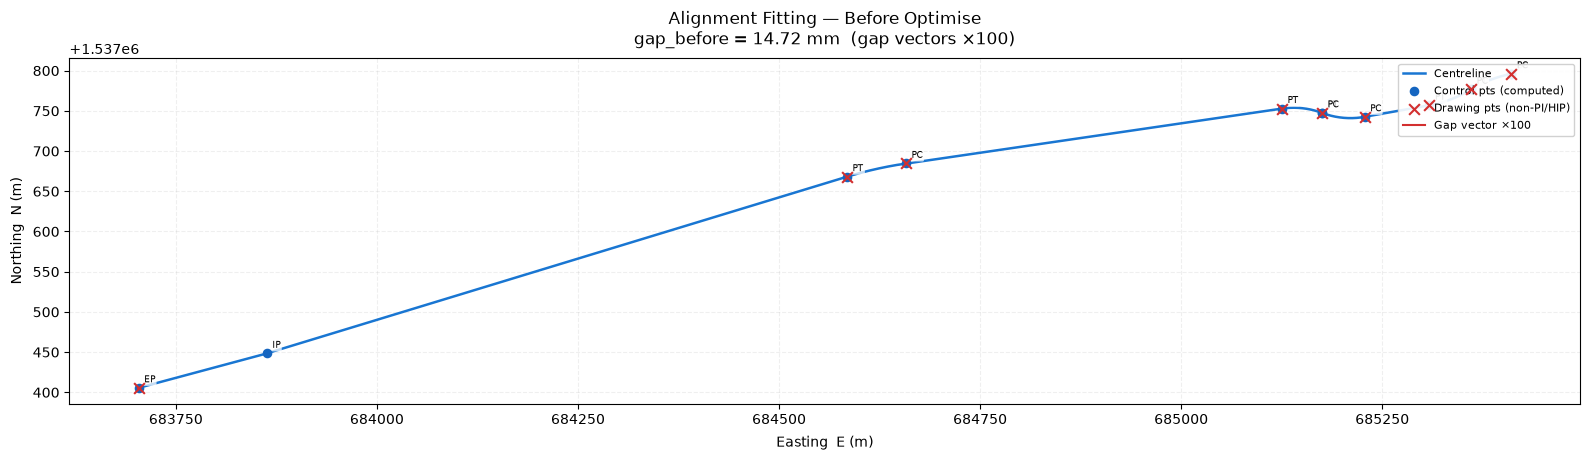

In [2]:
# ── Section 2: helper functions + before-optimise plot ─────────────────────
_MAGNIFY = 100  # gap vector scale factor


def _compute_gaps(elements, pts):
    """Return per-point dict: name, sta, draw_n/e, calc_n/e, gap_m."""
    out = []
    for dp in pts:
        try:
            calc = calculate_station_to_coordinate(elements, dp['sta'])
            gap  = math.hypot(dp['n'] - calc.n, dp['e'] - calc.e)
            out.append({'name': dp['name'], 'sta': dp['sta'],
                        'draw_n': dp['n'],  'draw_e': dp['e'],
                        'calc_n': calc.n,   'calc_e': calc.e,  'gap_m': gap})
        except (ValueError, IndexError):
            out.append({'name': dp['name'], 'sta': dp['sta'],
                        'draw_n': dp['n'],  'draw_e': dp['e'],
                        'calc_n': float('nan'), 'calc_e': float('nan'),
                        'gap_m': float('nan')})
    return out


def _trace_centreline(elements, n_steps=60):
    """Sample (E, N) along the computed centre line."""
    E, N = [], []
    for el in elements:
        L = el.sta_end - el.sta_start
        for i in range(n_steps + 1):
            s = calculate_point_on_element(el, L * i / n_steps)
            E.append(s.e)
            N.append(s.n)
    return E, N


def _plot_alignment(build_result, gap_data, title, magnify=_MAGNIFY):
    """Plot centre line, control points, drawing points, and gap vectors."""
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.set_aspect('equal')

    # Centre line
    ce, cn = _trace_centreline(build_result.elements)
    ax.plot(ce, cn, color='#1976D2', lw=1.8, label='Centreline', zorder=2)

    # Computed control points (blue filled circles)
    for i, cp in enumerate(build_result.control):
        ax.scatter(cp.e, cp.n, color='#1565C0', s=35, zorder=4,
                   label='Control pts (computed)' if i == 0 else None)
        ax.annotate(cp.name, (cp.e, cp.n), fontsize=6.5,
                    xytext=(4, 4), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.15',
                              fc='white', ec='none', alpha=0.75))

    # Drawing points (red X)
    for i, g in enumerate(gap_data):
        ax.scatter(g['draw_e'], g['draw_n'],
                   color='#D32F2F', s=60, marker='x', linewidths=1.5, zorder=6,
                   label='Drawing pts (non-PI/HIP)' if i == 0 else None)

    # Gap vectors x magnify (red lines from calc_pt to calc_pt + magnify * gap_vec)
    for g in gap_data:
        if math.isnan(g['gap_m']):
            continue
        dE = g['draw_e'] - g['calc_e']
        dN = g['draw_n'] - g['calc_n']
        ax.plot([g['calc_e'], g['calc_e'] + magnify * dE],
                [g['calc_n'], g['calc_n'] + magnify * dN],
                color='#D32F2F', lw=1.5, zorder=7)

    # Legend (add gap vector proxy line)
    handles, _ = ax.get_legend_handles_labels()
    handles.append(Line2D([0], [0], color='#D32F2F', lw=1.5,
                          label=f'Gap vector ×{magnify}'))
    ax.legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.9)

    ax.set_xlabel('Easting  E (m)', labelpad=6)
    ax.set_ylabel('Northing  N (m)', labelpad=6)
    ax.set_title(title, pad=10)
    ax.grid(True, alpha=0.2, ls='--')
    plt.tight_layout()
    return fig


# Compute before-gaps and plot
gaps_before = _compute_gaps(build_before.elements, active_pts)
_rms_before = math.sqrt(sum(
    g['gap_m'] ** 2 for g in gaps_before if not math.isnan(g['gap_m'])
))

_title_before = (
    'Alignment Fitting — Before Optimise\n'
    f'gap_before = {_rms_before * 1000:.2f} mm  (gap vectors ×{_MAGNIFY})'
)
fig2 = _plot_alignment(build_before, gaps_before, _title_before)
plt.show()


## Section 3 — Run Optimizer

Calls `fit_radius(pi_rows, drawing_points)` — Nelder-Mead optimisation over the
free PI radii to minimise Σgap² between calculated and drawing coordinates.
Displays R_initial vs R_optimized and gap_before vs gap_after.


In [3]:
# ── Section 3: Run Optimizer ────────────────────────────────────────────────
result = fit_radius(pi_rows, drawing_points)

print(f'Optimised {len(result.names)} free radii over {result.n_points} check points')
print(f'Converged  : {result.converged}  |  {result.iterations} iterations')
print(f'Message    : {result.message}')
print()
print(f'{"PI":<8}  {"R_initial":>12}  {"R_optimized":>12}  {"delta_R":>10}')
print('-' * 48)
for _n, _r0, _r1 in zip(result.names, result.r_initial, result.r_optimized):
    print(f'{_n:<8}  {_r0:>12.3f}  {_r1:>12.3f}  {_r1 - _r0:>+10.3f}')
print()
print(f'gap_before  = {result.gap_before * 1000:.3f} mm')
print(f'gap_after   = {result.gap_after  * 1000:.3f} mm')
_pct_total = (1 - result.gap_after / result.gap_before) * 100
print(f'improvement = {_pct_total:.1f} %')


Optimised 5 free radii over 9 check points
Converged  : True  |  289 iterations
Message    : Optimization terminated successfully.

PI           R_initial   R_optimized     delta_R
------------------------------------------------
PI1           -150.000      -149.905      +0.095
PI2            150.000       150.071      +0.071
PI3            100.000       100.022      +0.022
PI4           -100.000       -99.969      +0.031
PI5           -500.000      -499.985      +0.015

gap_before  = 14.717 mm
gap_after   = 1.206 mm
improvement = 91.8 %


## Section 4 — Alignment Plot (after optimise)

Rebuilds the alignment with optimised radii and re-plots with the same gap-vector scheme (×100 magnification).  Exports the figure to `notebooks/alignment_fitting.png`.


Exported: D:\My Second Project\SurveyorMicroToolkit\notebooks\alignment_fitting.png


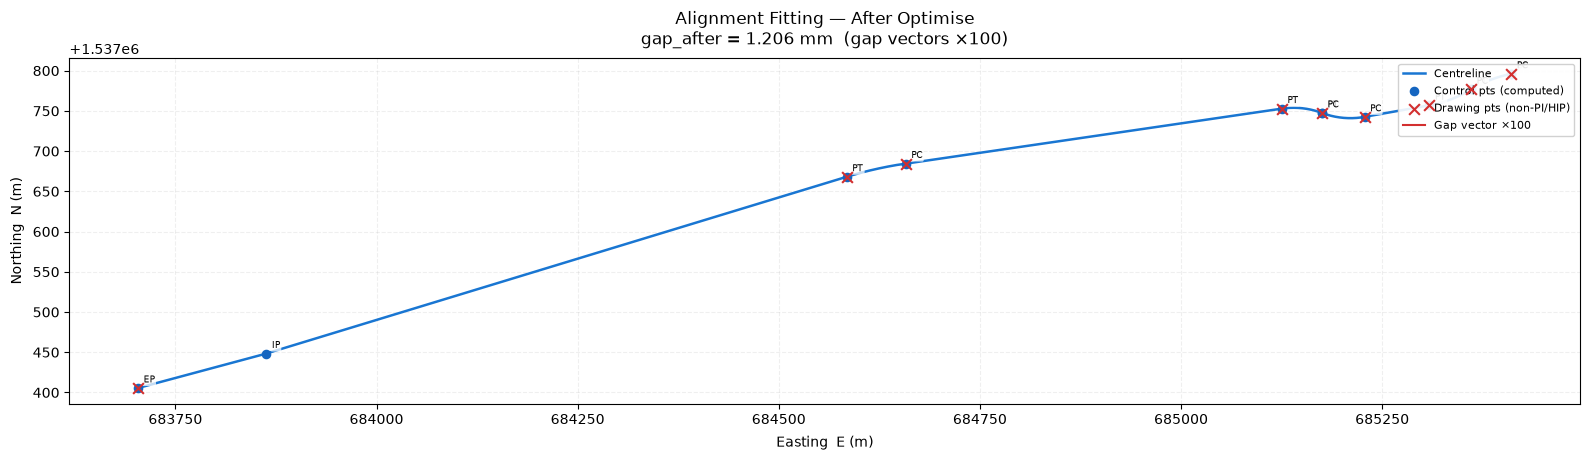

In [4]:
# ── Section 4: Rebuild with optimised R → plot → export PNG ─────────────────────
# Locate POINT and RADIUS columns in the PI header row
_hdr    = pi_rows[0]
_pt_col = next(j for j, c in enumerate(_hdr) if str(c).strip().lower() == 'point')
_r_col  = next(j for j, c in enumerate(_hdr)
               if str(c).strip().lower() in {'r', 'radius'})

# Patch a copy of pi_rows with optimised radii
_patched = [list(row) for row in pi_rows]
for _name, _r_opt in zip(result.names, result.r_optimized):
    for _i, _row in enumerate(_patched[1:], start=1):
        if str(_row[_pt_col]).strip() == _name:
            _patched[_i][_r_col] = str(_r_opt)
            break

build_after = build_alignment_from_pi(parse_pi_table(_patched))
gaps_after  = _compute_gaps(build_after.elements, active_pts)

_title_after = (
    'Alignment Fitting — After Optimise\n'
    f'gap_after = {result.gap_after * 1000:.3f} mm  (gap vectors ×{_MAGNIFY})'
)
fig4 = _plot_alignment(build_after, gaps_after, _title_after)

# Export PNG to notebooks/
_png_path = Path('alignment_fitting.png')
fig4.savefig(_png_path, dpi=150, bbox_inches='tight')
print(f'Exported: {_png_path.resolve()}')
plt.show()


## Section 5 — Comparison Table

Per-point gap (mm) before and after optimisation for every active drawing control point (non-PI/HIP).  Green bars show % improvement.


In [5]:
# ── Section 5: Comparison Table ──────────────────────────────────────────────
_rows = []
for _gb, _ga in zip(gaps_before, gaps_after):
    _impr = (1.0 - _ga['gap_m'] / _gb['gap_m']) * 100 if _gb['gap_m'] > 0 else 0.0
    _rows.append({
        'Name':            _gb['name'],
        'STA (m)':         round(_gb['sta'], 3),
        'gap_before (mm)': round(_gb['gap_m'] * 1000, 3),
        'gap_after (mm)':  round(_ga['gap_m'] * 1000, 3),
        'improvement (%)': round(_impr, 1),
    })

df = pd.DataFrame(_rows)

df.style \
    .format({
        'STA (m)':           '{:.3f}',
        'gap_before (mm)':   '{:.3f}',
        'gap_after (mm)':    '{:.3f}',
        'improvement (%)':   '{:.1f}',
    }) \
    .bar(subset=['improvement (%)'], color='#43A047', vmin=0, vmax=100) \
    .set_caption('Per-point gap before vs after optimisation')


,Name,STA (m),gap_before (mm),gap_after (mm),improvement (%)
0,BP,0.000,0.000,0.000,0.0
1,PC,53.874,1.826,0.087,95.2
2,PT,109.663,2.302,0.540,76.5
3,PC,191.438,2.729,0.294,89.2
4,PT,245.304,2.942,0.259,91.2
5,PT,295.946,7.425,0.727,90.2
6,PC,768.423,6.791,0.228,96.6
7,PT,843.738,6.259,0.461,92.6
8,EP,1762.869,7.172,0.456,93.6
